In [1]:
# -*- coding: utf-8 -*-
"""
Majority-vote baseline for ROADMAP mood completion prediction
- Predicts completion on Day t using majority of prior days (0..t-1)
- Also outputs a probability = (# prior Yes) / (# prior days)
- Evaluates TP/FP/TN/FN, accuracy, and cross-entropy
"""

import json
from pathlib import Path
from typing import Dict, Any, List, Tuple, Optional
import math
import pandas as pd
import numpy as np

# -----------------
# Configuration
# -----------------
JSON_PATH = Path("participants_data.json")  # Path to participant data
START_DAY = 1     # Start from day 1 (day 0 has no prior data)
END_DAY = 120     # Inclusive end day
EPS = 1e-9        # For cross-entropy stability
OUT_CSV = Path("majority_vote_predictions.csv")

# -----------------
# Helper Functions
# -----------------
def parse_day_key(k: Any) -> Optional[int]:
    """Parse day key from various formats (e.g., 'Day 0', '0', etc.)"""
    if k is None:
        return None
    s = str(k).strip()
    if s.lower().startswith("day "):
        s = s.split(" ", 1)[1].strip()
    try:
        d = int(s)
    except Exception:
        return None
    return d

def extract_mood_series(node: Dict[str, Any]) -> Dict[int, float]:
    """Extract {day: mood_float} for days with numeric mood values (completed surveys)."""
    mood_map = node.get("Mood", {}) or {}
    day_to_mood: Dict[int, float] = {}
    for k, v in mood_map.items():
        d = parse_day_key(k)
        if d is None:
            continue
        try:
            val = float(v)
        except Exception:
            # Skip non-numeric values (e.g., "missing") - treated as non-completed
            continue
        day_to_mood[d] = val
    return day_to_mood

def majority_vote_prior(day_to_mood: Dict[int, float], t: int) -> Tuple[float, str]:
    """
    Compute prior completion rate up to day t-1, and a majority-vote label.
    
    Args:
        day_to_mood: Dictionary mapping days to mood values (completed days)
        t: Current day to predict
        
    Returns:
        Tuple of (p_hat, pred_label) where:
        - p_hat: Probability estimate (prior completion rate)
        - pred_label: "Yes" or "No" based on majority vote
    """
    if t <= 0:
        return 0.5, "Yes"  # Tie-breaking policy for empty history
    
    prior_days = range(0, t)
    yes_count = sum(1 for d in prior_days if d in day_to_mood)  # Numeric mood = Yes
    total_prior_days = t  # Number of prior days (0..t-1)
    
    p_hat = yes_count / total_prior_days if total_prior_days > 0 else 0.5
    pred_label = "Yes" if p_hat >= 0.5 else "No"
    
    return p_hat, pred_label

def cross_entropy(y_true: int, p: float) -> float:
    """Calculate binary cross-entropy loss."""
    p = min(max(p, EPS), 1.0 - EPS)
    return -(y_true * math.log(p) + (1 - y_true) * math.log(1 - p))

# -----------------
# Data Loading
# -----------------
def load_participant_data() -> Dict[str, Any]:
    """Load participant data from JSON file."""
    if not JSON_PATH.exists():
        raise FileNotFoundError(f"Cannot find {JSON_PATH.resolve()}")
    
    with JSON_PATH.open("r", encoding="utf-8") as f:
        participants = json.load(f)
    
    return participants

# -----------------
# Main Prediction Pipeline
# -----------------
def run_majority_vote_baseline() -> pd.DataFrame:
    """
    Run majority vote baseline prediction for all participants and days.
    
    Returns:
        DataFrame with columns: id, day, p_hat, pred, true, cross_entropy
    """
    participants = load_participant_data()
    rows: List[Dict[str, Any]] = []
    
    for pid, node in participants.items():
        if not isinstance(node, dict):
            continue
            
        day_to_mood = extract_mood_series(node)
        
        for day in range(START_DAY, END_DAY + 1):
            # Get prediction and probability
            p_hat, pred = majority_vote_prior(day_to_mood, day)
            
            # Determine ground truth
            y_true_label = "Yes" if day in day_to_mood else "No"
            y_true = 1 if y_true_label == "Yes" else 0
            
            # Calculate cross-entropy loss
            ce_loss = cross_entropy(y_true, p_hat)
            
            rows.append({
                "id": pid,
                "day": day,
                "p_hat": p_hat,
                "pred": pred,
                "true": y_true_label,
                "cross_entropy": ce_loss
            })
    
    return pd.DataFrame(rows)

def calculate_performance_metrics(df: pd.DataFrame) -> Dict[str, float]:
    """Calculate overall performance metrics."""
    tp = int(((df["pred"] == "Yes") & (df["true"] == "Yes")).sum())
    fp = int(((df["pred"] == "Yes") & (df["true"] == "No")).sum())
    tn = int(((df["pred"] == "No") & (df["true"] == "No")).sum())
    fn = int(((df["pred"] == "No") & (df["true"] == "Yes")).sum())
    
    total_examples = len(df)
    overall_accuracy = (tp + tn) / total_examples if total_examples > 0 else 0
    mean_cross_entropy = float(df["cross_entropy"].mean()) if len(df) > 0 else float("nan")
    
    return {
        "true_positives": tp,
        "false_positives": fp,
        "true_negatives": tn,
        "false_negatives": fn,
        "total_examples": total_examples,
        "accuracy": overall_accuracy,
        "mean_cross_entropy": mean_cross_entropy
    }

def print_performance_summary(metrics: Dict[str, float], df: pd.DataFrame):
    """Print comprehensive performance summary."""
    print("=" * 60)
    print("MAJORITY VOTE BASELINE PERFORMANCE SUMMARY")
    print("=" * 60)
    print(f"Participants: {df['id'].nunique():,}")
    print(f"Days evaluated: {START_DAY}..{END_DAY} (inclusive)")
    print(f"Total predictions: {metrics['total_examples']:,}")
    print(f"True Positives: {metrics['true_positives']:,}")
    print(f"False Positives: {metrics['false_positives']:,}")
    print(f"True Negatives: {metrics['true_negatives']:,}")
    print(f"False Negatives: {metrics['false_negatives']:,}")
    print(f"Overall Accuracy: {metrics['accuracy']:.4f}")
    print(f"Mean Cross-Entropy: {metrics['mean_cross_entropy']:.6f}")
    
    # Calculate additional metrics
    precision = metrics['true_positives'] / (metrics['true_positives'] + metrics['false_positives']) if (metrics['true_positives'] + metrics['false_positives']) > 0 else 0
    recall = metrics['true_positives'] / (metrics['true_positives'] + metrics['false_negatives']) if (metrics['true_positives'] + metrics['false_negatives']) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

# -----------------
# Main Execution
# -----------------
if __name__ == "__main__":
    # Run predictions
    print("Running majority vote baseline predictions...")
    df = run_majority_vote_baseline()
    
    # Calculate metrics
    metrics = calculate_performance_metrics(df)
    
    # Print summary
    print_performance_summary(metrics, df)
    
    # Display sample predictions
    print("\nSample Predictions:")
    print("-" * 40)
    display(df.sample(min(10, len(df)), random_state=42))
    
    # Save predictions to CSV
    df.to_csv(OUT_CSV, index=False)
    print(f"\nSaved detailed predictions to: {OUT_CSV.resolve()}")
    
    # Print key day statistics
    print("\n" + "=" * 60)
    print("ACCURACY AT KEY DAYS")
    print("=" * 60)
    
    key_days = [0, 20, 40, 60, 80, 100, 120]
    for day in key_days:
        if day >= START_DAY and day <= END_DAY:
            day_data = df[df["day"] == day]
            if len(day_data) > 0:
                day_accuracy = ((day_data["pred"] == day_data["true"]).sum()) / len(day_data)
                print(f"Day {day:3d}: {day_accuracy:.3f} (n={len(day_data)})")
            else:
                print(f"Day {day:3d}: No data available")
        else:
            print(f"Day {day:3d}: Outside evaluation range")

Running majority vote baseline predictions...
MAJORITY VOTE BASELINE PERFORMANCE SUMMARY
Participants: 334
Days evaluated: 1..120 (inclusive)
Total predictions: 40,080
True Positives: 14,452
False Positives: 5,368
True Negatives: 17,557
False Negatives: 2,703
Overall Accuracy: 0.7986
Mean Cross-Entropy: 0.555461
Precision: 0.7292
Recall: 0.8424
F1-Score: 0.7817

Sample Predictions:
----------------------------------------


,id,day,p_hat,pred,true,cross_entropy
33099,P007,100,0.060000,No,No,6.187540e-02
1697,P239,18,0.888889,Yes,Yes,1.177830e-01
19392,P191,73,0.000000,No,No,1.000000e-09
36837,P045,118,0.008475,No,No,8.510690e-03
7359,P319,40,0.225000,No,Yes,1.491655e+00
27070,P009,71,0.816901,Yes,Yes,2.022369e-01
27731,P148,12,0.166667,No,No,1.823216e-01
32389,P024,110,0.745455,Yes,No,1.368276e+00
21284,P040,45,0.977778,Yes,Yes,2.247286e-02
734,P218,15,0.000000,No,No,1.000000e-09



Saved detailed predictions to: /users/c/h/chenshun/roadmap/ROADMAP-2.0-LLM-Behavioral-Simulation-Pipeline/majority_vote_predictions.csv

ACCURACY AT KEY DAYS
Day   0: Outside evaluation range
Day  20: 0.787 (n=334)
Day  40: 0.823 (n=334)
Day  60: 0.790 (n=334)
Day  80: 0.811 (n=334)
Day 100: 0.805 (n=334)
Day 120: 0.740 (n=334)


/tmp/ipykernel_3728293/2116876451.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg = g.apply(lambda x: pd.Series({
/tmp/ipykernel_3728293/2116876451.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg = g.apply(lambda x: pd.Series({



DETAILED METRIC VALUES FOR KEY DAYS (MAJORITY VOTE BASELINE)

TRUE POSITIVE RATE:
------------------------------------------------------------
Day  Patients     Caregivers  
------------------------------
0    N/A          N/A         
20   0.815        0.839       
40   0.845        0.857       
60   0.742        0.900       
80   0.764        0.939       
100  0.852        0.922       
120  0.714        0.806       

FALSE POSITIVE RATE:
------------------------------------------------------------
Day  Patients     Caregivers  
------------------------------
0    N/A          N/A         
20   0.157        0.378       
40   0.156        0.275       
60   0.149        0.345       
80   0.188        0.282       
100  0.168        0.320       
120  0.212        0.350       

TRUE NEGATIVE RATE:
------------------------------------------------------------
Day  Patients     Caregivers  
------------------------------
0    N/A          N/A         
20   0.843        0.622       
40   0.84

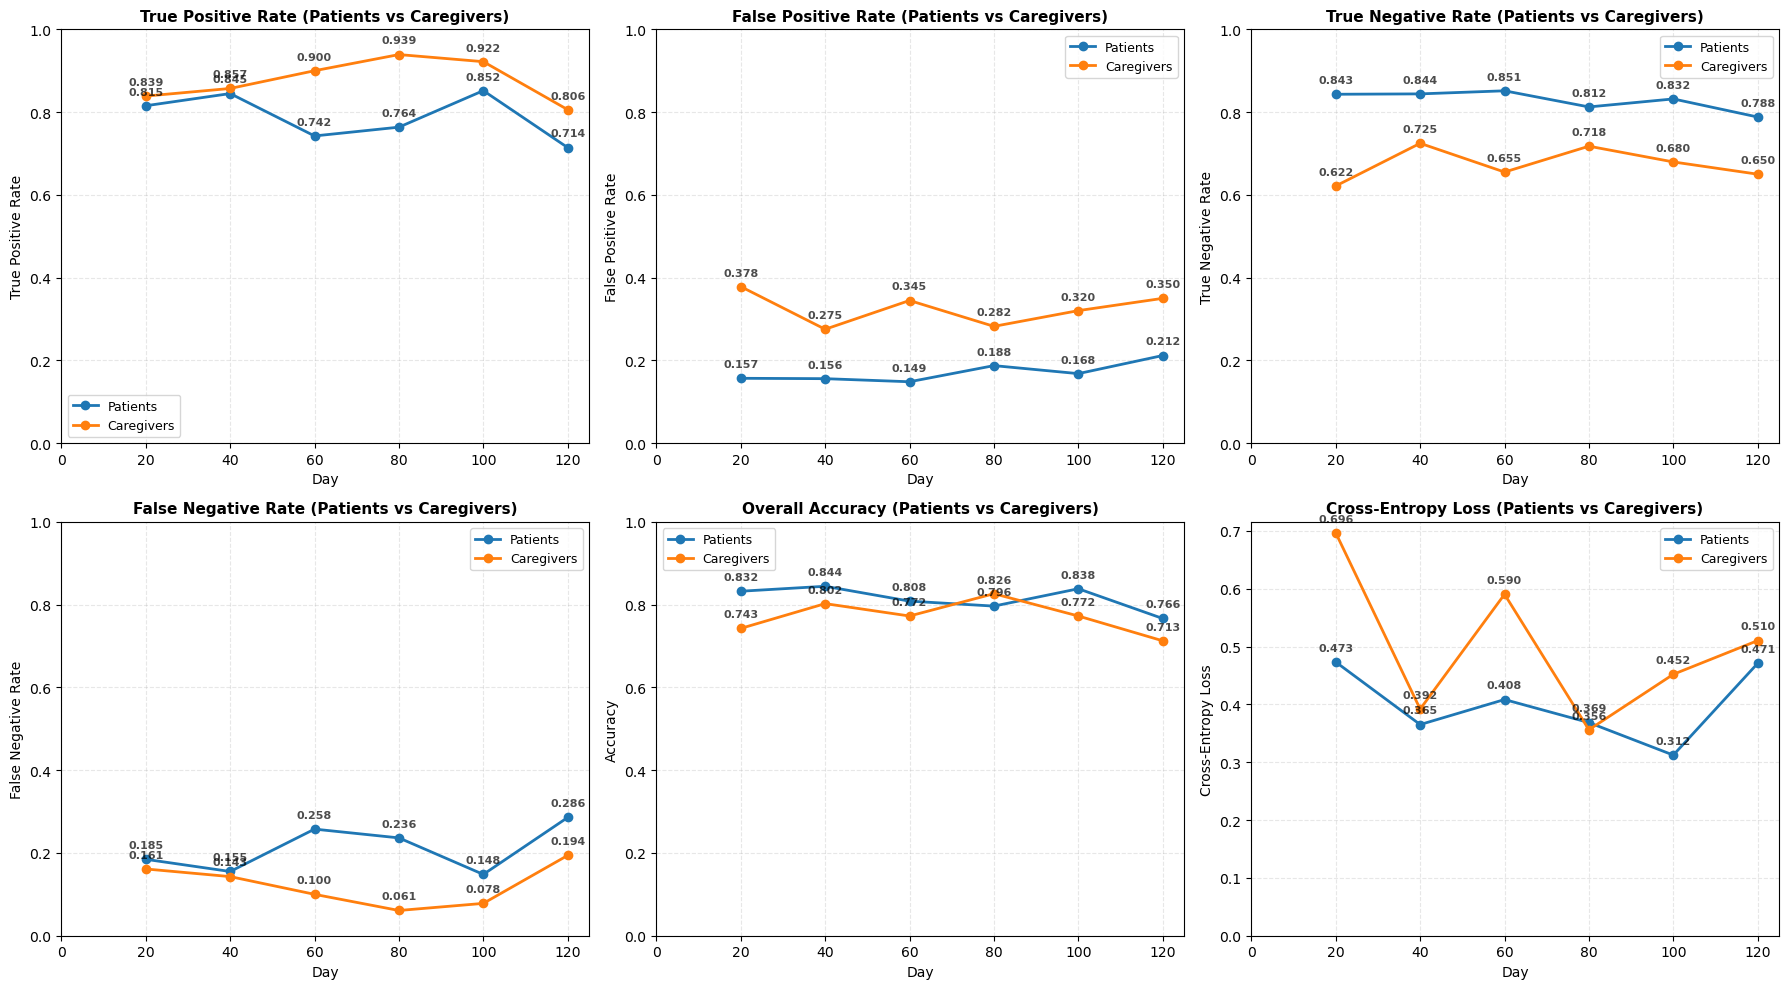


SUMMARY STATISTICS BY ROLE (KEY DAYS ONLY)

Patients:
----------------------------------------
  True Positive Rate: 0.789 ± 0.057
  False Positive Rate: 0.171 ± 0.024
  True Negative Rate: 0.829 ± 0.024
  False Negative Rate: 0.211 ± 0.057
  Accuracy: 0.814 ± 0.030
  Cross-Entropy: 0.400 ± 0.064

Caregivers:
----------------------------------------
  True Positive Rate: 0.877 ± 0.052
  False Positive Rate: 0.325 ± 0.040
  True Negative Rate: 0.675 ± 0.040
  False Negative Rate: 0.123 ± 0.052
  Accuracy: 0.771 ± 0.041
  Cross-Entropy: 0.500 ± 0.128

CONFUSION MATRIX SUMMARY FOR KEY DAYS

Patients:
----------------------------------------
  Total TP: 274.0
  Total FP: 113.0
  Total TN: 542.0
  Total FN: 73.0
  Total samples: 1002.0
  Overall Accuracy: 0.814

Caregivers:
----------------------------------------
  Total TP: 424.0
  Total FP: 169.0
  Total TN: 349.0
  Total FN: 60.0
  Total samples: 1002.0
  Overall Accuracy: 0.771


In [2]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PRED_CSV = Path("majority_vote_predictions.csv")
JSON_PATH = Path("participants_data.json")

if not PRED_CSV.exists():
    raise FileNotFoundError(f"Cannot find {PRED_CSV.resolve()}. Run the majority-vote generation first.")
if not JSON_PATH.exists():
    raise FileNotFoundError(f"Cannot find {JSON_PATH.resolve()}.")

# ---------- Load predictions ----------
df = pd.read_csv(PRED_CSV)

# ---------- Load id -> role mapping ----------
with JSON_PATH.open("r", encoding="utf-8") as f:
    participants = json.load(f)

id_to_role = {}
for pid, node in participants.items():
    if not isinstance(node, dict):
        continue
    demo = node.get("Demographic", {}) or {}
    role = demo.get("role")
    if role in ("Patients", "Caregivers"):
        id_to_role[pid] = role

df["role"] = df["id"].map(id_to_role)
df = df[df["role"].isin(["Patients", "Caregivers"])].copy()

# Define key days for analysis
KEY_DAYS = [0, 20, 40, 60, 80, 100, 120]

# ---------- Helpers to compute confusion + metrics ----------
def per_day_confusion(sub: pd.DataFrame) -> pd.DataFrame:
    """
    Return DataFrame indexed by 'day' with TP/FP/TN/FN counts and derived metrics.
    """
    g = sub.groupby("day", as_index=False)

    def _count_tp(x): return int(((x["pred"] == "Yes") & (x["true"] == "Yes")).sum())
    def _count_fp(x): return int(((x["pred"] == "Yes") & (x["true"] == "No")).sum())
    def _count_tn(x): return int(((x["pred"] == "No")  & (x["true"] == "No")).sum())
    def _count_fn(x): return int(((x["pred"] == "No")  & (x["true"] == "Yes")).sum())

    agg = g.apply(lambda x: pd.Series({
        "TP": _count_tp(x),
        "FP": _count_fp(x),
        "TN": _count_tn(x),
        "FN": _count_fn(x),
        "N":  len(x),
        "CE": x["cross_entropy"].mean()
    })).reset_index()

    # Metrics
    # TPR = TP / (TP + FN)
    agg["TPR"] = agg.apply(lambda r: (r["TP"] / (r["TP"] + r["FN"])) if (r["TP"] + r["FN"]) > 0 else np.nan, axis=1)
    # FPR = FP / (FP + TN)
    agg["FPR"] = agg.apply(lambda r: (r["FP"] / (r["FP"] + r["TN"])) if (r["FP"] + r["TN"]) > 0 else np.nan, axis=1)
    # TNR = TN / (TN + FP)
    agg["TNR"] = agg.apply(lambda r: (r["TN"] / (r["TN"] + r["FP"])) if (r["TN"] + r["FP"]) > 0 else np.nan, axis=1)
    # FNR = FN / (FN + TP)
    agg["FNR"] = agg.apply(lambda r: (r["FN"] / (r["FN"] + r["TP"])) if (r["FN"] + r["TP"]) > 0 else np.nan, axis=1)
    # Accuracy
    agg["ACC"] = agg.apply(
        lambda r: (r["TP"] + r["TN"]) / max(1, (r["TP"] + r["FP"] + r["TN"] + r["FN"])), axis=1
    )

    return agg.sort_values("day")

# Filter data to only include key days
df_key_days = df[df["day"].isin(KEY_DAYS)].copy()

metrics_by_role = {
    role: per_day_confusion(df_key_days[df_key_days["role"] == role]) for role in ["Patients", "Caregivers"]
}

# ---------- Print detailed point values for key days ----------
print("\n" + "="*100)
print("DETAILED METRIC VALUES FOR KEY DAYS (MAJORITY VOTE BASELINE)")
print("="*100)

# Create a combined dataframe for easier printing
combined_data = []
for role in ["Patients", "Caregivers"]:
    role_data = metrics_by_role[role]
    for _, row in role_data.iterrows():
        combined_data.append({
            'role': role,
            'day': row['day'],
            'tpr': row['TPR'],
            'fpr': row['FPR'],
            'tnr': row['TNR'],
            'fnr': row['FNR'],
            'acc': row['ACC'],
            'ce': row['CE'],
            'TP': row['TP'],
            'FP': row['FP'],
            'TN': row['TN'],
            'FN': row['FN'],
            'N': row['N']
        })

combined_df = pd.DataFrame(combined_data)

# Print table for each metric
metrics_to_print = ['tpr', 'fpr', 'tnr', 'fnr', 'acc', 'ce']
metric_names = {
    'tpr': 'True Positive Rate',
    'fpr': 'False Positive Rate', 
    'tnr': 'True Negative Rate',
    'fnr': 'False Negative Rate',
    'acc': 'Accuracy',
    'ce': 'Cross-Entropy'
}

for metric in metrics_to_print:
    print(f"\n{metric_names[metric].upper()}:")
    print("-" * 60)
    
    # Pivot table for better formatting
    pivot_data = combined_df.pivot(index='day', columns='role', values=metric)
    
    # Print header
    header = f"{'Day':<4} {'Patients':<12} {'Caregivers':<12}"
    print(header)
    print("-" * len(header))
    
    # Print values for each key day
    for day in KEY_DAYS:
        if day in pivot_data.index:
            patients_val = pivot_data.loc[day, 'Patients'] if 'Patients' in pivot_data.columns else np.nan
            caregivers_val = pivot_data.loc[day, 'Caregivers'] if 'Caregivers' in pivot_data.columns else np.nan
            
            patients_str = f"{patients_val:.3f}" if not np.isnan(patients_val) else "N/A"
            caregivers_str = f"{caregivers_val:.3f}" if not np.isnan(caregivers_val) else "N/A"
            
            print(f"{day:<4} {patients_str:<12} {caregivers_str:<12}")
        else:
            print(f"{day:<4} {'N/A':<12} {'N/A':<12}")

# ---------- Plot all metrics in 2x3 grid ----------
def plot_all_metrics_grid(metrics_by_role, key_days):
    """Plot all 6 metrics in a 2x3 grid layout"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    metric_configs = [
        ("TPR", "True Positive Rate", "True Positive Rate (Patients vs Caregivers)"),
        ("FPR", "False Positive Rate", "False Positive Rate (Patients vs Caregivers)"),
        ("TNR", "True Negative Rate", "True Negative Rate (Patients vs Caregivers)"),
        ("FNR", "False Negative Rate", "False Negative Rate (Patients vs Caregivers)"),
        ("ACC", "Accuracy", "Overall Accuracy (Patients vs Caregivers)"),
        ("CE", "Cross-Entropy Loss", "Cross-Entropy Loss (Patients vs Caregivers)")
    ]
    
    for i, (metric_key, ylabel, title) in enumerate(metric_configs):
        ax = axes[i]
        
        for role in ["Patients", "Caregivers"]:
            role_data = metrics_by_role[role]
            # Filter to only key days
            key_day_data = role_data[role_data["day"].isin(key_days)]
            
            ax.plot(key_day_data["day"], key_day_data[metric_key], 
                   marker="o", linewidth=2, markersize=6, label=role)
            
            # Add value annotations
            for _, row in key_day_data.iterrows():
                value = row[metric_key]
                if not np.isnan(value):
                    ax.annotate(f'{value:.3f}', 
                               (row["day"], value),
                               textcoords="offset points",
                               xytext=(0,8),
                               ha='center',
                               fontsize=8,
                               alpha=0.7,
                               fontweight='bold')
        
        ax.set_xlabel("Day", fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.grid(True, linestyle="--", alpha=0.3)
        ax.legend(fontsize=9)
        ax.set_xticks(key_days)
        
        # Set appropriate y-axis limits
        if metric_key == 'CE':
            ax.set_ylim(bottom=0)
        else:
            ax.set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()

# Generate the grid plot
plot_all_metrics_grid(metrics_by_role, KEY_DAYS)

# ---------- Print summary statistics ----------
print("\n" + "="*80)
print("SUMMARY STATISTICS BY ROLE (KEY DAYS ONLY)")
print("="*80)

for role in ["Patients", "Caregivers"]:
    print(f"\n{role}:")
    print("-" * 40)
    
    role_data = combined_df[combined_df['role'] == role]
    
    for metric in metrics_to_print:
        values = role_data[metric].dropna()
        if len(values) > 0:
            mean_val = values.mean()
            std_val = values.std()
            print(f"  {metric_names[metric]}: {mean_val:.3f} ± {std_val:.3f}")
        else:
            print(f"  {metric_names[metric]}: No valid data")

# ---------- Print confusion matrix summary ----------
print("\n" + "="*80)
print("CONFUSION MATRIX SUMMARY FOR KEY DAYS")
print("="*80)

for role in ["Patients", "Caregivers"]:
    print(f"\n{role}:")
    print("-" * 40)
    
    role_data = combined_df[combined_df['role'] == role]
    total_tp = role_data['TP'].sum()
    total_fp = role_data['FP'].sum()
    total_tn = role_data['TN'].sum()
    total_fn = role_data['FN'].sum()
    total_n = role_data['N'].sum()
    
    print(f"  Total TP: {total_tp}")
    print(f"  Total FP: {total_fp}")
    print(f"  Total TN: {total_tn}")
    print(f"  Total FN: {total_fn}")
    print(f"  Total samples: {total_n}")
    print(f"  Overall Accuracy: {(total_tp + total_tn) / total_n:.3f}")

/tmp/ipykernel_3157447/2166702745.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg = g.apply(lambda x: pd.Series({



OVERALL ACCURACY VALUES FOR KEY DAYS (MAJORITY VOTE BASELINE)

Day  Accuracy   TP     FP     TN     FN     Total   
------------------------------------------------------------
10   0.808       142.0  47.0   128.0  17.0   334.0   
20   0.787       131.0  44.0   132.0  27.0   334.0   
30   0.796       132.0  39.0   134.0  29.0   334.0   
40   0.823       133.0  36.0   142.0  23.0   334.0   
50   0.775       121.0  49.0   138.0  26.0   334.0   
60   0.790       121.0  45.0   143.0  25.0   334.0   
70   0.811       117.0  50.0   154.0  13.0   334.0   
80   0.811       119.0  45.0   152.0  18.0   334.0   
90   0.811       113.0  45.0   158.0  18.0   334.0   
100  0.805       105.0  52.0   164.0  13.0   334.0   
110  0.835       117.0  35.0   162.0  20.0   334.0   
120  0.740       89.0   60.0   158.0  27.0   334.0   


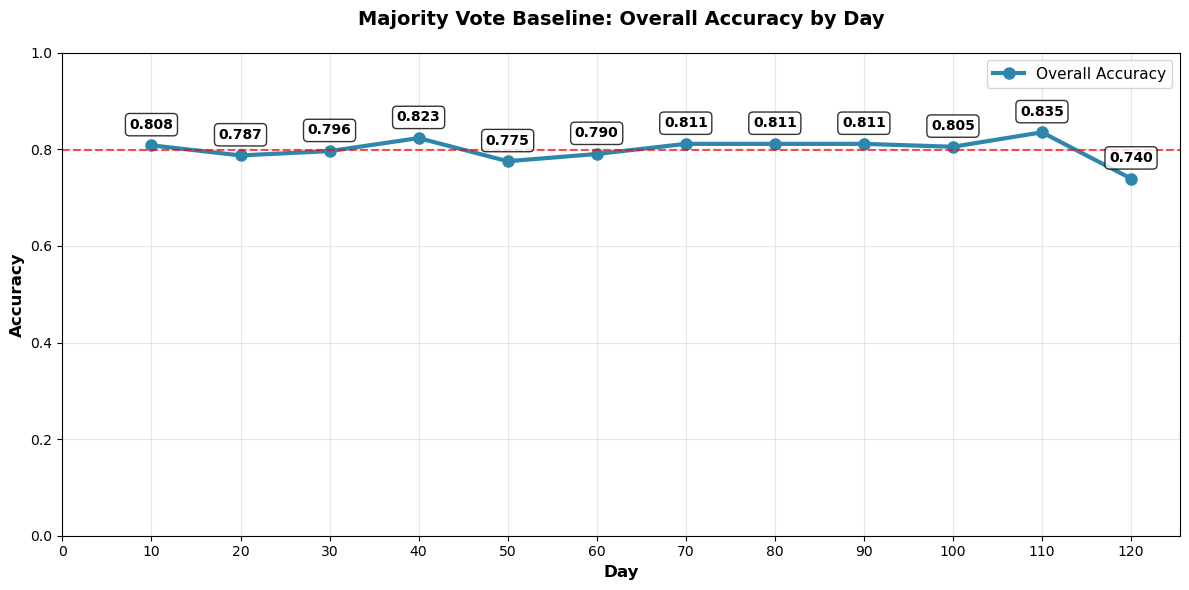


SUMMARY STATISTICS
Total Samples: 4,008.0
True Positives (TP): 1,440.0
False Positives (FP): 547.0
True Negatives (TN): 1,765.0
False Negatives (FN): 256.0
Overall Accuracy: 0.800
Precision: 0.725
Recall: 0.849
F1-Score: 0.782

Daily Accuracy Statistics:
Mean: 0.800
Standard Deviation: 0.025
Minimum: 0.740
Maximum: 0.835


In [3]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PRED_CSV = Path("majority_vote_predictions.csv")
JSON_PATH = Path("participants_data.json")

if not PRED_CSV.exists():
    raise FileNotFoundError(f"Cannot find {PRED_CSV.resolve()}. Run the majority-vote generation first.")
if not JSON_PATH.exists():
    raise FileNotFoundError(f"Cannot find {JSON_PATH.resolve()}.")

# ---------- Load predictions ----------
df = pd.read_csv(PRED_CSV)

# Define key days for analysis (every 10 days from 0 to 120)
KEY_DAYS = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]

# Filter data to only include key days
df_key_days = df[df["day"].isin(KEY_DAYS)].copy()

# ---------- Compute overall accuracy metrics ----------
def compute_overall_accuracy(df_subset: pd.DataFrame) -> pd.DataFrame:
    """
    Compute overall accuracy metrics without role distinction.
    Returns DataFrame with accuracy metrics for each day.
    """
    g = df_subset.groupby("day", as_index=False)

    def _count_tp(x): return int(((x["pred"] == "Yes") & (x["true"] == "Yes")).sum())
    def _count_fp(x): return int(((x["pred"] == "Yes") & (x["true"] == "No")).sum())
    def _count_tn(x): return int(((x["pred"] == "No")  & (x["true"] == "No")).sum())
    def _count_fn(x): return int(((x["pred"] == "No")  & (x["true"] == "Yes")).sum())

    agg = g.apply(lambda x: pd.Series({
        "TP": _count_tp(x),
        "FP": _count_fp(x),
        "TN": _count_tn(x),
        "FN": _count_fn(x),
        "N":  len(x),
        "CE": x["cross_entropy"].mean()
    })).reset_index()

    # Compute accuracy
    agg["ACC"] = agg.apply(
        lambda r: (r["TP"] + r["TN"]) / max(1, (r["TP"] + r["FP"] + r["TN"] + r["FN"])), axis=1
    )

    return agg.sort_values("day")

# Compute overall metrics (all participants combined)
overall_metrics = compute_overall_accuracy(df_key_days)

# ---------- Print detailed accuracy values ----------
print("\n" + "="*80)
print("OVERALL ACCURACY VALUES FOR KEY DAYS (MAJORITY VOTE BASELINE)")
print("="*80)

print(f"\n{'Day':<4} {'Accuracy':<10} {'TP':<6} {'FP':<6} {'TN':<6} {'FN':<6} {'Total':<8}")
print("-" * 60)

for _, row in overall_metrics.iterrows():
    day = int(row['day'])
    accuracy = row['ACC']
    tp = row['TP']
    fp = row['FP']
    tn = row['TN']
    fn = row['FN']
    total = row['N']
    
    print(f"{day:<4} {accuracy:.3f}{'':<6} {tp:<6} {fp:<6} {tn:<6} {fn:<6} {total:<8}")

# ---------- Plot overall accuracy ----------
def plot_overall_accuracy(overall_metrics, key_days):
    """Plot overall accuracy trend with value annotations"""
    plt.figure(figsize=(12, 6))
    
    # Plot accuracy line
    plt.plot(overall_metrics["day"], overall_metrics["ACC"], 
             marker="o", linewidth=3, markersize=8, 
             color='#2E86AB', label='Overall Accuracy')
    
    # Add value annotations
    for _, row in overall_metrics.iterrows():
        accuracy = row['ACC']
        day = row['day']
        plt.annotate(f'{accuracy:.3f}', 
                    (day, accuracy),
                    textcoords="offset points",
                    xytext=(0,12),
                    ha='center',
                    fontsize=10,
                    fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    # Customize plot
    plt.title('Majority Vote Baseline: Overall Accuracy by Day', 
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Day', fontsize=12, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.xticks(key_days)
    plt.ylim(0, 1)
    
    # Add average accuracy line
    avg_accuracy = overall_metrics["ACC"].mean()
    plt.axhline(y=avg_accuracy, color='red', linestyle='--', alpha=0.7, 
                label=f'Average: {avg_accuracy:.3f}')
    
    plt.tight_layout()
    plt.show()

# Generate the plot
plot_overall_accuracy(overall_metrics, KEY_DAYS)

# ---------- Print summary statistics ----------
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

total_tp = overall_metrics['TP'].sum()
total_fp = overall_metrics['FP'].sum()
total_tn = overall_metrics['TN'].sum()
total_fn = overall_metrics['FN'].sum()
total_samples = overall_metrics['N'].sum()
overall_accuracy = (total_tp + total_tn) / total_samples

print(f"Total Samples: {total_samples:,}")
print(f"True Positives (TP): {total_tp:,}")
print(f"False Positives (FP): {total_fp:,}")
print(f"True Negatives (TN): {total_tn:,}")
print(f"False Negatives (FN): {total_fn:,}")
print(f"Overall Accuracy: {overall_accuracy:.3f}")

# Calculate additional metrics
precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1_score:.3f}")

# Daily accuracy statistics
daily_accuracies = overall_metrics["ACC"].dropna()
if len(daily_accuracies) > 0:
    print(f"\nDaily Accuracy Statistics:")
    print(f"Mean: {daily_accuracies.mean():.3f}")
    print(f"Standard Deviation: {daily_accuracies.std():.3f}")
    print(f"Minimum: {daily_accuracies.min():.3f}")
    print(f"Maximum: {daily_accuracies.max():.3f}")